In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress


k_B = 1.380649e-23  # Boltzmann constant (J/K)
m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
P = 0.25 * 18.131842  # Pressure (Pascal)
r_D_e = 0.0016622715189364113

g = 9.8  # free fall acceleration (m/s^2)
rho = 1500  # mass density of dust particle
T_p = 300  # Kinetic temperature of dust particles motion
r_p = 4.445e-6  # Dust particle radius
m_p = 4.0 / 3.0 * np.pi * r_p**3 * rho

V_T_p = np.sqrt(2 * k_B * T_p / m_p)

In [111]:
def display_with_mean(
    ts: np.array, data: np.array, title: str, y_label: str, is_log=False, is_plot=False
):
    if is_plot:
        t_min = np.min(ts)
        t_max = np.max(ts)

        plt.figure(dpi=100)
        plt.title(f"{title}")
        plt.xlabel(r"$t, ns$")
        plt.ylabel(f"{y_label}")
        plt.grid()
        plt.plot(ts, data, "-")
        plt.hlines(
            np.mean(data[1_000:]),
            1.1 * t_min,
            t_max,
            colors="red",
            linestyles="--",
            label=f"{np.mean(data[1_000:]):10f}",
        )
        plt.legend(loc="best")
        plt.show()

    if is_log:
        return np.mean(data[1_000:]), np.std(np.log(data[1_000:]))
    else:
        return np.mean(data[1_000:]), np.std(data[1_000:])

In [128]:
from statsmodels.tsa.stattools import adfuller


rs1 = []
rs2 = []
vs1 = []
vs2 = []
rs1_var = []
rs2_var = []
vs1_var = []
vs2_var = []

wakes = np.array(
    [
        0.0,
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
        1.1,
        1.2,
        1.3,
        1.4,
        1.5,
        1.6,
        1.7,
        1.8,
        1.9,
        2.0,
    ]
)

for i in wakes:
    data = np.genfromtxt(f"../data/new_wakes/data_{i}.txt", delimiter="\t")

    rs_1 = np.sqrt(np.square(data[:, 1]) + np.square(data[:, 2]))
    rs_2 = np.sqrt(np.square(data[:, 4]) + np.square(data[:, 5]))
    zs_1 = data[:, 3]
    vzs_1 = data[:, 6]

    vs_1 = np.sqrt(np.square(data[:, 7]) + np.square(data[:, 8]))
    vs_2 = np.sqrt(np.square(data[:, 7 + 3]) + np.square(data[:, 8 + 3]))
    zs_2 = data[:, 9]
    vzs_2 = data[:, 12]

    t = (data[:, 0]) / 2.0 * 50.0
    t_min = np.min(t)
    t_max = np.max(t)

    k_B = 1.380649e-23  # Boltzmann constant (J/K)
    m_i = 6.6335209e-26  # Ar+ ions' mass (kg)
    P = 0.25 * 18.131842  # Pressure (Pascal)
    r_D_e = 0.0016622715189364113

    mean1, var1 = display_with_mean(t, rs_1 / r_D_e, f"1st_{i}", "r, r_D_e")
    mean2, var2 = display_with_mean(t, rs_2 / r_D_e, f"2nd_{i}", "r, r_D_e")

    v_mean1, v_var1 = display_with_mean(t, vs_1, f"1st_{i}", "v, m/s")
    v_mean2, v_var2 = display_with_mean(t, vs_2, f"2nd_{i}", "v, m/s")

    rs1 += [mean1]
    rs2 += [mean2]
    rs1_var += [var1]
    rs2_var += [var2]

    vs1 += [v_mean1]
    vs2 += [v_mean2]
    vs1_var += [v_var1]
    vs2_var += [v_var2]


rs1 = np.array(rs1)
rs2 = np.array(rs2)
rs1_var = np.array(rs1_var)
rs2_var = np.array(rs2_var)

vs1 = np.array(vs1)
vs2 = np.array(vs2)
vs1_var = np.array(vs1_var)
vs2_var = np.array(vs2_var)

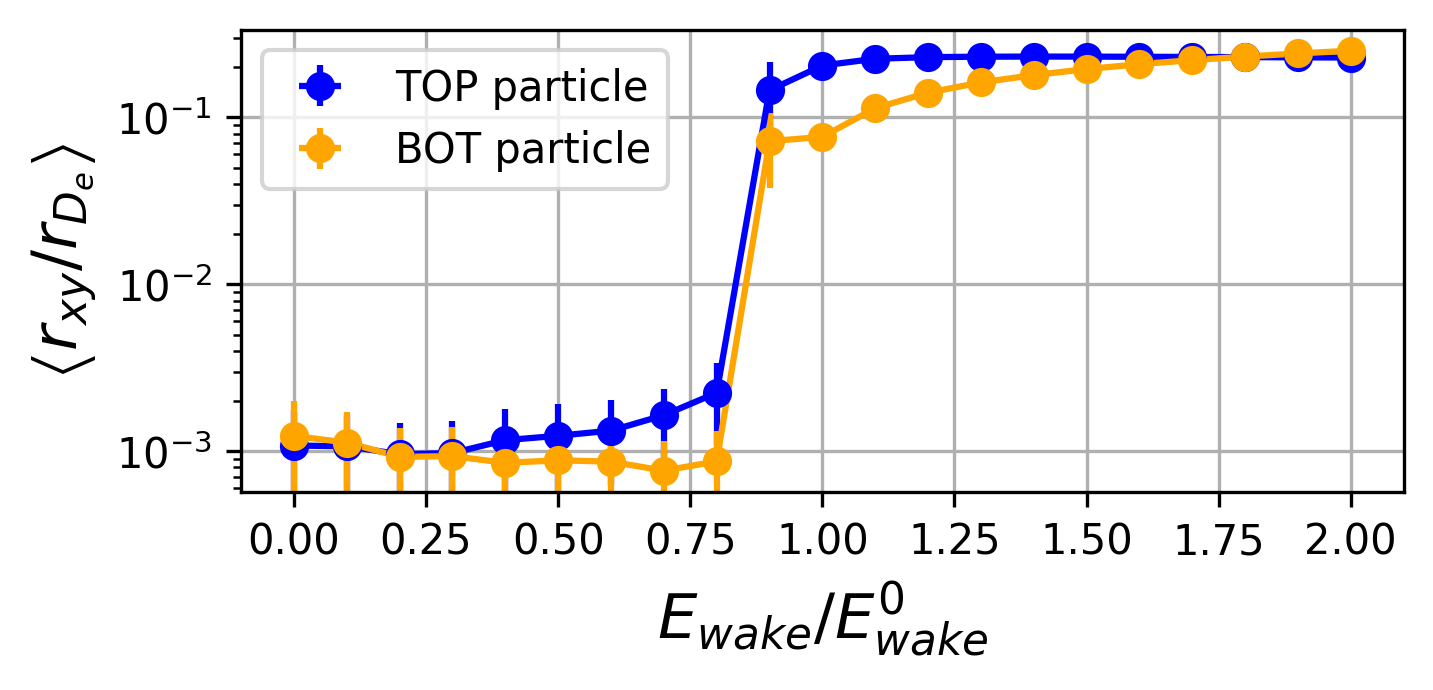

In [145]:
plt.figure(dpi=300, figsize=(5, 2))
plt.xlabel(r"$E_{wake} / E_{wake}^0$", fontsize=15)
plt.ylabel(r"$\left<r_{xy} / r_{D_e}\right>$", fontsize=15)
plt.grid()
plt.yscale("log")
plt.errorbar(wakes, rs1, rs1_var, 0, "o", label="TOP particle", color="blue")
plt.errorbar(wakes, rs2, rs2_var, 0, "o", label="BOT particle", color="orange")
plt.plot(wakes, rs1, "-", color="blue")
plt.plot(wakes, rs2, "-", color="orange")
plt.legend(loc="best")
plt.show()

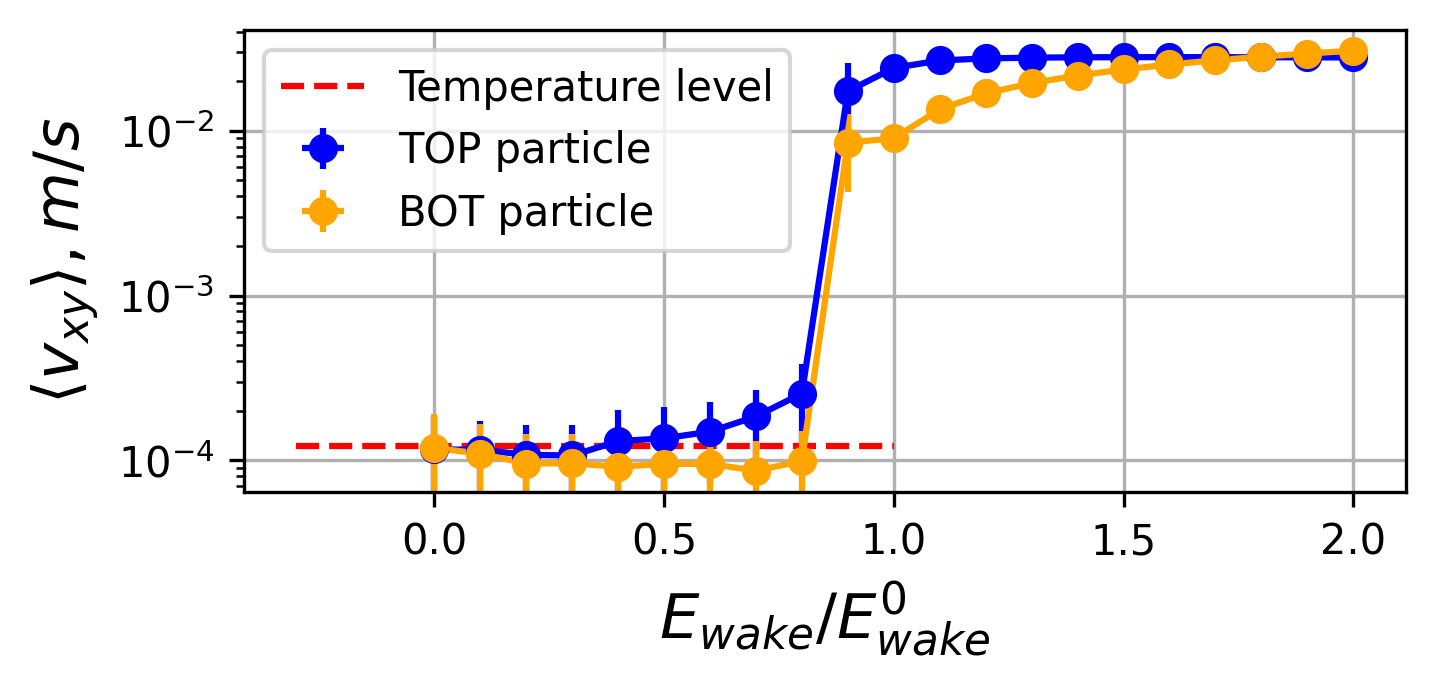

In [144]:
plt.figure(dpi=300, figsize=(5, 2))
plt.xlabel(r"$E_{wake} / E_{wake}^0$", fontsize=15)
plt.ylabel(r"$\left<v_{xy}\right>, m/s$", fontsize=15)
plt.yscale("log")
plt.grid()
plt.hlines(V_T_p, -0.3, 1.0, "red", "--", label="Temperature level")
plt.errorbar(wakes, vs1, vs1_var, 0, "o", label="TOP particle", color="blue")
plt.errorbar(wakes, vs2, vs2_var, 0, "o", label="BOT particle", color="orange")
plt.plot(wakes, vs1, "-", color="blue")
plt.plot(wakes, vs2, "-", color="orange")
plt.legend(loc="best")
plt.show()

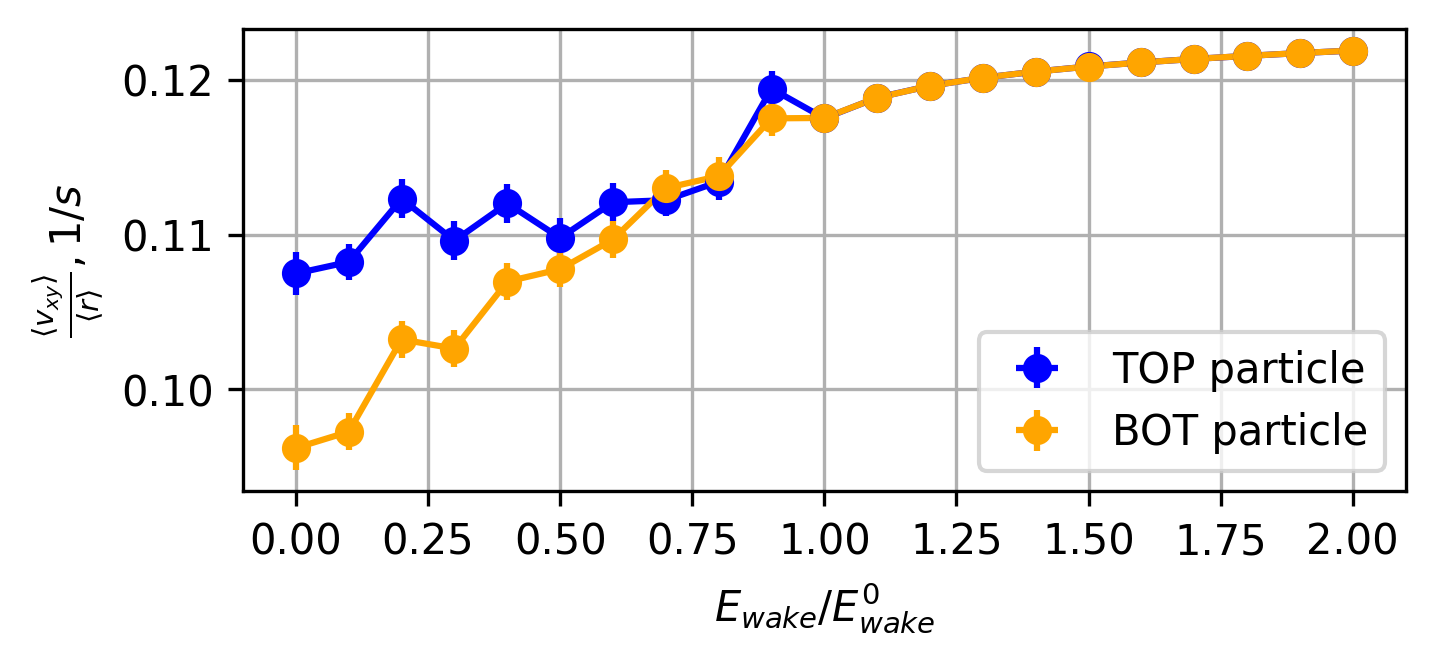

In [133]:
plt.figure(dpi=300, figsize=(5, 2))
plt.xlabel(r"$E_{wake} / E_{wake}^0$")
plt.ylabel(r"$\frac{\left<v_{xy}\right>}{\left<r\right>}, 1/s$")
plt.grid()
plt.errorbar(
    wakes,
    vs1 / rs1,
    np.sqrt(np.square(vs1_var / vs1) + np.square(rs1_var / rs1)) * r_D_e,
    0,
    "o",
    label="TOP particle",
    color="blue",
)
plt.errorbar(
    wakes,
    vs2 / rs2,
    np.sqrt(np.square(vs2_var / vs2) + np.square(rs2_var / rs2)) * r_D_e,
    0,
    "o",
    label="BOT particle",
    color="orange",
)
plt.plot(wakes, vs1 / rs1, "-", color="blue")
plt.plot(wakes, vs2 / rs2, "-", color="orange")
plt.legend(loc="best")
plt.show()

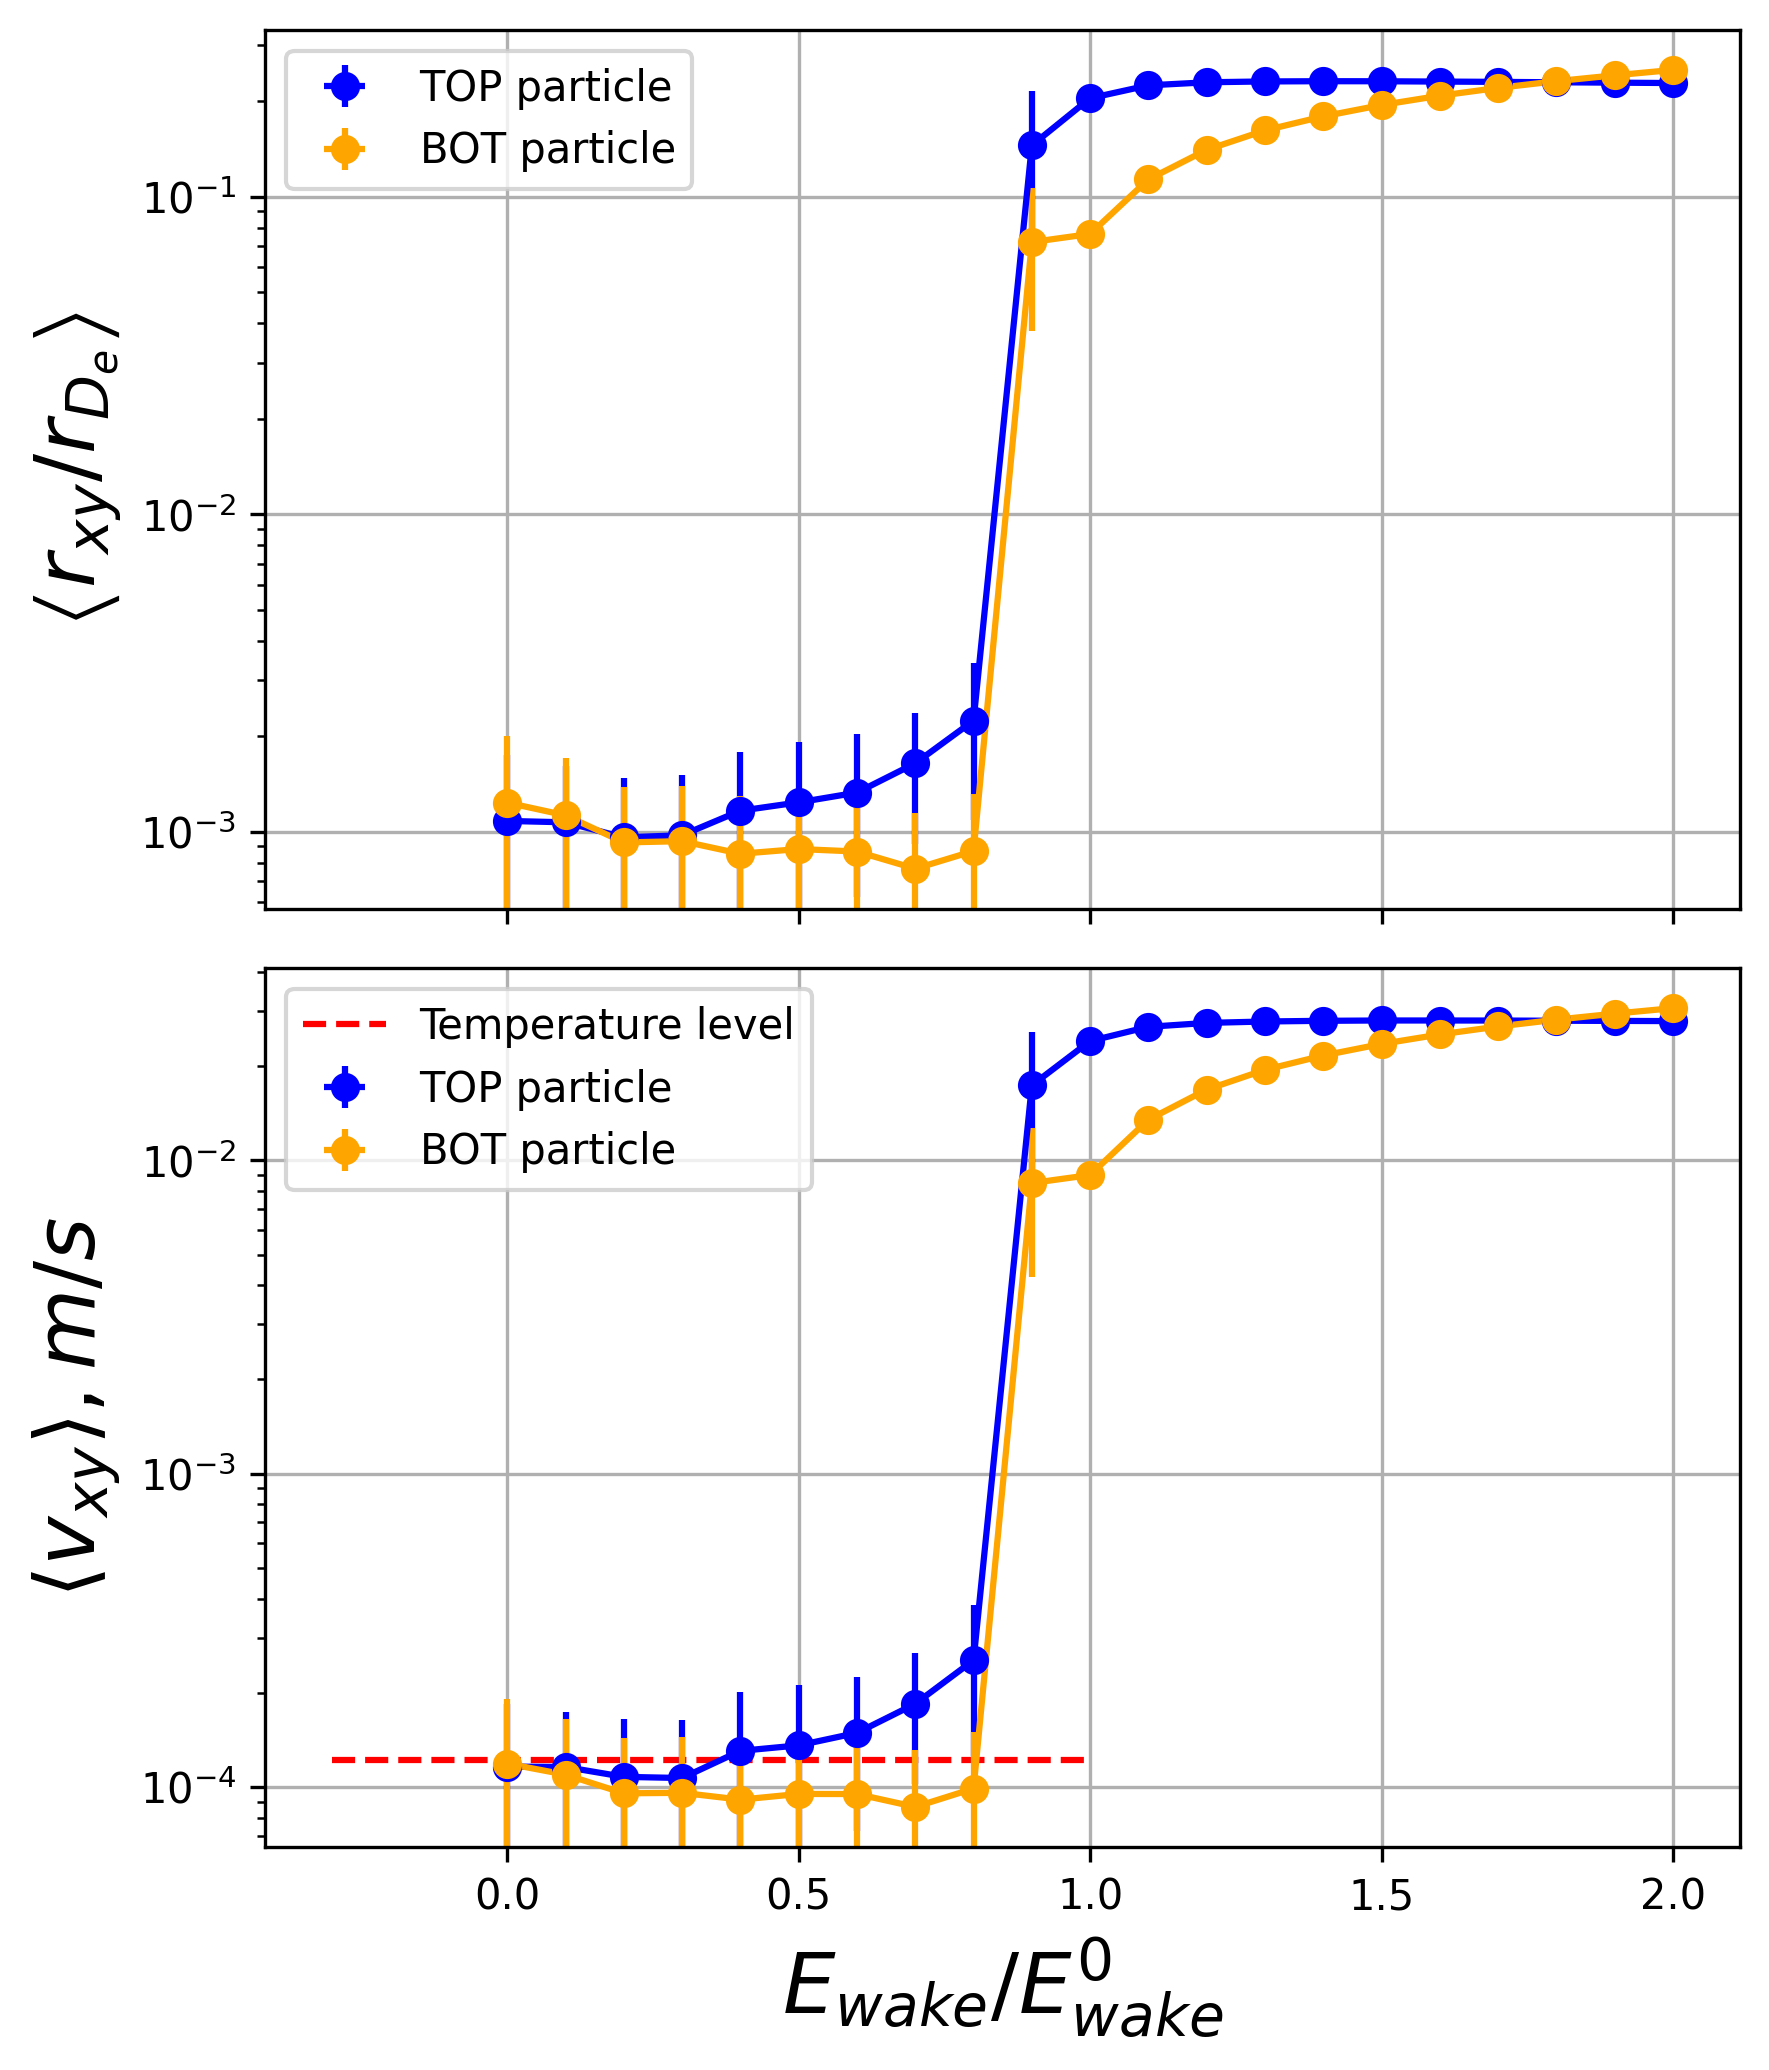

In [150]:
# Создаем фигуру с двумя подграфиками (2 строки, 1 столбец)
fig, (ax1, ax2) = plt.subplots(2, 1, dpi=300, figsize=(6, 7), sharex=True)

# Верхний график (скорости)
ax2.set_ylabel(r"$\left<v_{xy}\right>, m/s$", fontsize=20)
ax2.set_yscale("log")
ax2.grid()
ax2.hlines(V_T_p, -0.3, 1.0, "red", "--", label="Temperature level")
ax2.errorbar(wakes, vs1, vs1_var, 0, "o", label="TOP particle", color="blue")
ax2.errorbar(wakes, vs2, vs2_var, 0, "o", label="BOT particle", color="orange")
ax2.plot(wakes, vs1, "-", color="blue")
ax2.plot(wakes, vs2, "-", color="orange")
ax2.legend(loc="best")

# Нижний график (радиусы)
ax1.set_ylabel(r"$\left<r_{xy} / r_{D_e}\right>$", fontsize=20)
ax1.set_yscale("log")
ax1.grid()
ax1.errorbar(wakes, rs1, rs1_var, 0, "o", label="TOP particle", color="blue")
ax1.errorbar(wakes, rs2, rs2_var, 0, "o", label="BOT particle", color="orange")
ax1.plot(wakes, rs1, "-", color="blue")
ax1.plot(wakes, rs2, "-", color="orange")
ax1.legend(loc="best")

# Общая подпись оси X (только для нижнего графика)
ax2.set_xlabel(r"$E_{wake} / E_{wake}^0$", fontsize=20)

# Автоматическая регулировка расстояния между графиками
plt.tight_layout()
plt.show()